In [1]:
# Clone the IPPy image restoration tool
!git clone https://github.com/NicolasCola7/IPPy.git

Cloning into 'IPPy'...
remote: Enumerating objects: 389, done.
remote: Counting objects: 100% (389/389), done.
remote: Compressing objects: 100% (279/279), done.
remote: Total 389 (delta 188), reused 288 (delta 90), pack-reused 0 (from 0)
Receiving objects: 100% (389/389), 7.24 MiB | 18.92 MiB/s, done.
Resolving deltas: 100% (188/188), done.


In [2]:
# Instal dependencies
!pip install numpy torch torchvision numba astra-toolbox scikit-image Pillow matplotlib cupy-cuda12x tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 100.1 MB/s eta 0:00:00


In [3]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:
# Imports
import glob
import math
import sys
import os
from pathlib import Path
from IPython.display import clear_output

import matplotlib.pyplot as plt
import torch
torch.cuda.empty_cache()
import gc
gc.collect()

from PIL import Image
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm
import numpy as np

repo_path = os.path.abspath('/content/IPPy')
if repo_path not in sys.path:
    sys.path.append(repo_path)

from IPPy import operators
from IPPy import utilities
from IPPy.nn.diffusion import DiffusionUNet, cosine_beta_schedule, extract, denormalize_to_01, EMA

In [5]:
# Setup
book_root = Path('.').resolve()
drive_dir = book_root / "drive" / "MyDrive" / "COMPUTATIONAL_IMAGING"
weights_dir = drive_dir / 'weights'
weights_path = weights_dir / 'DiffPir.pth'
raw_weights_path = weights_dir / 'DiffPir_raw.pth'
checkpoint_path = weights_dir / 'DiffPir.ckpt'
weights_dir.mkdir(exist_ok=True)
dataset_dir = drive_dir / "Mayo"

print('Weights directory:', weights_dir)

Weights directory: /content/drive/MyDrive/COMPUTATIONAL_IMAGING/weights


Device: cuda
Training images: 3306
Test images: 327
Weights directory: /content/drive/MyDrive/COMPUTATIONAL_IMAGING/weights


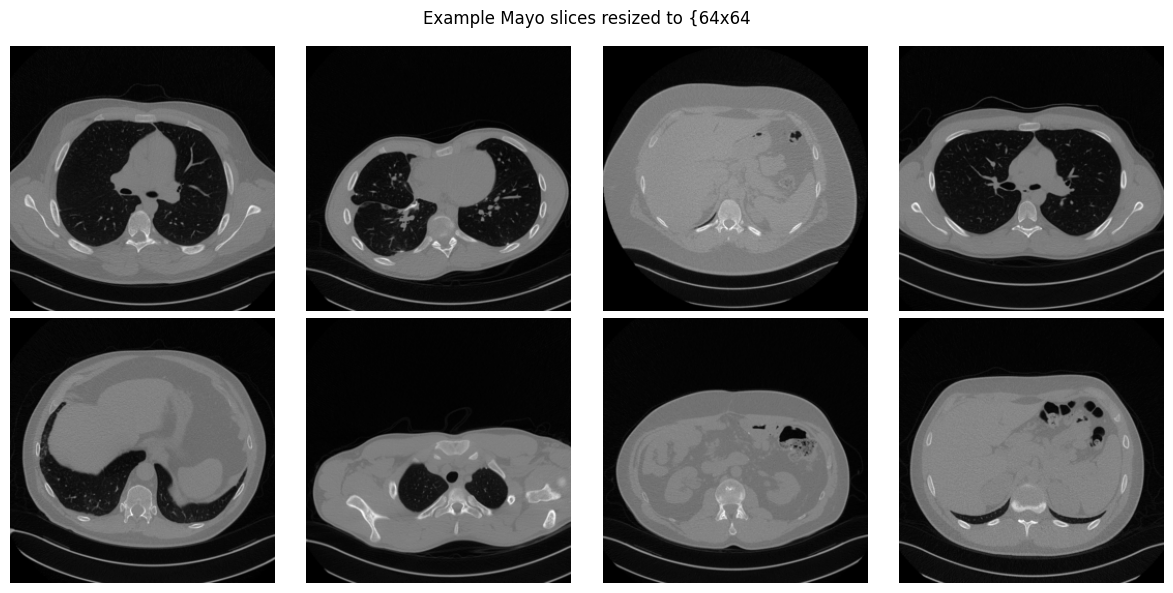

In [6]:
# Dataset setup
class MayoDataset(Dataset):
    def __init__(self, data_path, data_shape=256):
        super().__init__()
        self.fname_list = sorted(glob.glob(f'{data_path}/*/*.png'))
        self.transform = transforms.Compose([
            transforms.Resize((data_shape, data_shape), antialias=True),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ])

    def __len__(self):
        return len(self.fname_list)

    def __getitem__(self, idx):
        x = Image.open(self.fname_list[idx]).convert('L')
        return self.transform(x)

def show_batch(batch, title, ncols=4):
    batch = batch.detach().cpu()
    n = min(len(batch), 8)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
    axes = axes.reshape(-1) if hasattr(axes, 'reshape') else [axes]
    for ax, image in zip(axes, batch[:n]):
        ax.imshow(image.squeeze(), cmap='gray')
        ax.axis('off')
    for ax in axes[n:]:
        ax.axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

device = utilities.get_device()
batch_size = 8

train_dataset = MayoDataset(data_path=str(dataset_dir / 'train'), data_shape=256)
test_dataset = MayoDataset(data_path=str(dataset_dir  / 'test'), data_shape=256)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=(device == 'cuda'))
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=(device == 'cuda'))

print('Device:', device)
print('Training images:', len(train_dataset))
print('Test images:', len(test_dataset))
print('Weights directory:', weights_dir)

x_batch = next(iter(train_loader))
show_batch(x_batch[:batch_size], 'Example Mayo slices resized to {64x64')

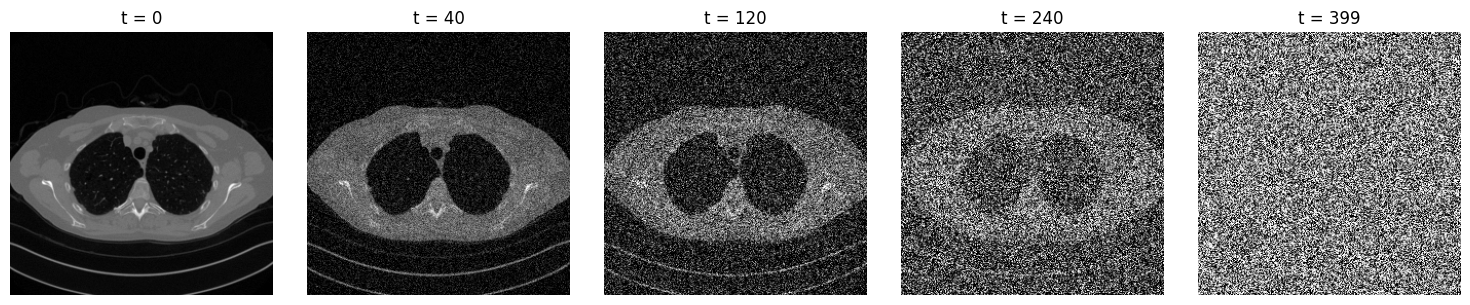

In [7]:
def make_beta_schedule(num_steps):
    '''
    Creates a noise schedule for num_steps.
    The result is a tensor that dictates how much noise is added at each timestep.
    '''
    return cosine_beta_schedule(num_steps)

def deterministic_ddim_update(x_t, x0_hat, eps_pred, t_next, alpha_bars):
    '''
    Perform a deterministic DDIM update.
    It computes the denoised image at the next timestep by simply adding back the model's predicted noise,
    scaled down by the next step's noise schedule (sqrt(1 - alpha_bar_next)), to the clean image estimate x0_hat.
    Because there is no random noise being injected at every step,
    the trajectory from pure noise to the clean image becomes a smooth, deterministic and predictable curve.
    '''
    if t_next < 0:
        return x0_hat
    alpha_bar_next = alpha_bars[t_next].to(x_t.device)
    return torch.sqrt(alpha_bar_next) * x0_hat + torch.sqrt(1 - alpha_bar_next) * eps_pred

num_diffusion_steps = 400
betas = make_beta_schedule(num_diffusion_steps) # noise schedule for n_diffusion_timesteps

alphas = 1.0 - betas # how much image structure is kept at each timestep

# The cumulative product of all alphas.
# It allows to compute any step x_t directly from x0 in a single equation. This is because the sum of 2 independent Gaussians is another Gaussian
alpha_bars = torch.cumprod(alphas, dim=0)

x0 = test_dataset[0].unsqueeze(0)
steps_to_show = [0, 40, 120, 240, 399]

fig, axes = plt.subplots(1, len(steps_to_show), figsize=(15, 3))
for ax, step in zip(axes, steps_to_show):
    t = torch.tensor([step], dtype=torch.long)
    noise = torch.randn_like(x0)
    x_t = extract(alpha_bars.sqrt(), t, x0.shape) * x0 + extract((1 - alpha_bars).sqrt(), t, x0.shape) * noise
    ax.imshow(denormalize_to_01(x_t).squeeze(), cmap='gray')
    ax.set_title(f't = {step}')
    ax.axis('off')
plt.tight_layout()
plt.show()


In [8]:
# Model setup
model = DiffusionUNet(
    in_ch=1,
    base_ch=64,
    channel_mults=(1, 1, 2, 2, 4),
    time_dim=256,
    dropout=0.1,
    attn_levels=(3, 4), # Apply attention ONLY at the 32x32 and 16x16 levels to save VRAM
)

num_params = sum(param.numel() for param in model.parameters())
print(model)
print(f'Trainable parameters: {num_params / 1e6:.2f}M')

DiffusionUNet(
  (init): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_mlp): Sequential(
    (0): Linear(in_features=256, out_features=1024, bias=True)
    (1): SiLU()
    (2): Linear(in_features=1024, out_features=256, bias=True)
  )
  (down_blocks): ModuleList(
    (0-1): 2 x ModuleList(
      (0-1): 2 x ResBlock(
        (norm1): GroupNorm(32, 64, eps=1e-05, affine=True)
        (act1): SiLU()
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (time_proj): Sequential(
          (0): SiLU()
          (1): Linear(in_features=256, out_features=64, bias=True)
        )
        (norm2): GroupNorm(32, 64, eps=1e-05, affine=True)
        (act2): SiLU()
        (dropout): Dropout(p=0.1, inplace=False)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (skip): Identity()
      )
      (2): Identity()
    )
    (2): ModuleList(
      (0): ResBlock(
        (norm1): GroupNorm(32, 64, eps=

In [ ]:
torch.manual_seed(0)

target_epochs = 500
save_every_n_epochs = 10
learning_rate = 2e-4
weight_decay = 1e-4
ema_decay = 0.9995
grad_clip = 1.0
force_restart = False

model.to(device)
ema = EMA(model, decay=ema_decay)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=target_epochs)

scaler = torch.amp.GradScaler('cuda', enabled=(device == 'cuda'))
autocast_device = 'cuda' if device == 'cuda' else 'cpu'

history = []
start_epoch = 0

if checkpoint_path.exists() and not force_restart:
    try:
        checkpoint = torch.load(checkpoint_path, map_location='cpu')
        model.load_state_dict(checkpoint['model'])
        ema.load_state_dict(checkpoint['ema'])
        optimizer.load_state_dict(checkpoint['optimizer'])
        scheduler.load_state_dict(checkpoint['scheduler'])
        scaler.load_state_dict(checkpoint['scaler'])
        for state in optimizer.state.values():
            for key, value in state.items():
                if isinstance(value, torch.Tensor):
                    state[key] = value.to(device)
        history = checkpoint.get('history', [])
        start_epoch = checkpoint.get('epoch', -1) + 1
        print(f'Resuming diffusion training from epoch {start_epoch + 1}.')

        del checkpoint
        gc.collect()
        torch.cuda.empty_cache()
    except Exception as exc:
        print(f'Ignoring incompatible checkpoint: {exc}')
        start_epoch = 0
        history = []
elif weights_path.exists() and not force_restart:
    try:
        ema_state = torch.load(weights_path, map_location='cpu')
        model.load_state_dict(ema_state)
        ema.shadow.load_state_dict(ema_state)
        start_epoch = target_epochs
        history = []
        print(f'Found existing EMA weights at {weights_path}. Skipping training.')
    except Exception as exc:
        print(f'Ignoring incompatible EMA weights: {exc}')
        start_epoch = 0
        history = []
else:
    print('Starting diffusion training from scratch.')

accumulation_steps = 4  # 4 steps * 8 physical batch size = 32 effective batch size

for epoch in range(start_epoch, target_epochs):
    model.train() # set the model to trian mode

    epoch_loss = 0.0

    progress_bar = tqdm(train_loader, desc=f'DDPM epoch {epoch + 1}/{target_epochs}', leave=True)

    # iterate over batches of clean images (x0) from the dataloader, starting the step counter at 1
    for step, x0_batch in enumerate(progress_bar, start=1):

        x0_batch = x0_batch.to(device, non_blocking=True)

        # 1. FORWARD DIFFUSION PROCESS

        # randomly sample a time step t for EVERY image in the batch independently.
        # This means image 1 might be at t=5 (mostly clean), while image 2 is at t=350 (mostly noise).
        t = torch.randint(0, num_diffusion_steps, (x0_batch.shape[0],), device=device)

        # generate a tensor of pure Gaussian noise
        noise = torch.randn_like(x0_batch)

        # jump directly to time step t using the closed-form math --> x_t = sqrt(alpha_bar_t) * x0 + sqrt(1 - alpha_bar_t) * pure_noise
        x_t = extract(alpha_bars.sqrt(), t, x0_batch.shape) * x0_batch + extract((1 - alpha_bars).sqrt(), t, x0_batch.shape) * noise

        # NEURAL NETWORK PREDICTION & LOSS

        # Enter the Automatic Mixed Precision (AMP) context. This automatically casts specific operations
        # to 16-bit floats (float16) to save VRAM and speed up math, while keeping critical layers in float32.
        with torch.autocast(device_type=autocast_device, dtype=torch.float16, enabled=(device == 'cuda')):

            noise_pred = model(x_t, t) # UNet tries to predict the pure noise added before for every image in x_t

            loss = F.mse_loss(noise_pred, noise) # MSE between predicted noise and actual noise

            # Divide the loss by the accumulation steps. Since we aren't updating the weights every batch,
            # we need to average the gradients over the total number of accumulation steps.
            loss = loss / accumulation_steps

        # BACKWARD PASS (Gradient Accumulation)

        # Use the AMP scaler to scale the loss up (preventing underflow in float16) and calculate
        # the gradients (backpropagation). The gradients are ADDED to the existing ones in the optimizer.
        scaler.scale(loss).backward()

        # OPTIMIZER STEP (Updating Weights)

        # Check if we have accumulated enough batches OR if it's the final batch of the epoch.
        if step % accumulation_steps == 0 or step == len(train_loader):

            # Unscale the gradients back to their normal float32 values so we can safely clip them.
            scaler.unscale_(optimizer)

            # Gradient Clipping, it prevents "exploding gradients" by capping the maximum gradient magnitude to 1.0.
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            # update the model's weights based on the accumulated gradients.
            scaler.step(optimizer)

            # Update the AMP scaler's internal scale factor for the next iteration based on whether
            # overflow was detected during this step.
            scaler.update()

            # flush the accumulated gradients out of the optimizer so we start fresh for the next block.
            optimizer.zero_grad(set_to_none=True)

            # Update the Exponential Moving Average (EMA) shadow model. It smoothly tracks the main
            # model's weights, resulting in a much more stable model for inference later.
            ema.update(model)

        # Because we divided the loss earlier for gradient math, we multiply it back here so
        # the numbers displayed reflects the true MSE error.
        true_loss = loss.item() * accumulation_steps

        # Add the true loss of this batch to the running epoch total.
        epoch_loss += true_loss

        # Update the tqdm progress bar to show the loss of this specific batch, and the average loss so far.
        progress_bar.set_postfix(loss=f'{true_loss:.5f}', avg=f'{epoch_loss / step:.5f}')

    # Calculate the average loss across all batches in this epoch.
    epoch_loss /= len(train_loader)

    # Append the average epoch loss to our history list so we can plot the loss curve later.
    history.append(epoch_loss)

    # Step the learning rate scheduler. Because we are using CosineAnnealingLR, this slightly adjusts
    # the learning rate down along a cosine curve to help the model settle into a minimum.
    scheduler.step()

    # save the "resume" checkpoint every epoch in case the run crashes
    checkpoint = {
        'epoch': epoch,
        'model': model.state_dict(),
        'ema': ema.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'scaler': scaler.state_dict(),
        'history': history,
        'config': {
            'target_epochs': target_epochs,
            'learning_rate': learning_rate,
            'weight_decay': weight_decay,
            'ema_decay': ema_decay,
            'grad_clip': grad_clip,
            'num_diffusion_steps': num_diffusion_steps,
        },
    }
    torch.save(checkpoint, checkpoint_path)

    # periodic checkpointing and final save
    is_final_epoch = (epoch + 1) == target_epochs
    is_save_epoch = (epoch + 1) % save_every_n_epochs == 0

    if is_save_epoch or is_final_epoch:
        print(f"\n--> Saving model weights at epoch {epoch + 1}")
        torch.save(ema.shadow.state_dict(), weights_path)
        torch.save(model.state_dict(), raw_weights_path)

if history:
    plt.figure(figsize=(5, 3))
    plt.plot(history)
    plt.title('DDPM training loss')
    plt.xlabel('Epoch')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

Resuming diffusion training from epoch 272.


DDPM epoch 272/500:   0%|          | 0/414 [00:00<?, ?it/s]

DDPM epoch 273/500:   0%|          | 0/414 [00:00<?, ?it/s]

DDPM epoch 274/500:   0%|          | 0/414 [00:00<?, ?it/s]

DDPM epoch 275/500:   0%|          | 0/414 [00:00<?, ?it/s]

...

DDPM epoch 293/500:   0%|          | 0/414 [00:00<?, ?it/s]

DDPM epoch 294/500:   0%|          | 0/414 [00:00<?, ?it/s]

DDPM epoch 295/500:   0%|          | 0/414 [00:00<?, ?it/s]

DDPM epoch 296/500:   0%|          | 0/414 [00:00<?, ?it/s]

DDPM epoch 297/500:   0%|          | 0/414 [00:00<?, ?it/s]

In [ ]:
def predict_x0_from_eps(x_t, eps_pred, t, alpha_bars):
    # Reconstruct the clean-image estimate from x_t and the predicted noise.
    return (x_t - extract((1 - alpha_bars).sqrt(), t, x_t.shape) * eps_pred) / extract(alpha_bars.sqrt(), t, x_t.shape)

def diffpir_reconstruct(model, y_delta, K, alpha_bars, sample_steps=40, tau=0.6):
    # Create a reverse-time schedule to skip steps.
    # Instead of taking 400 steps, we take a shortcut (e.g., 40 evenly spaced steps) down to 0.
    schedule = torch.linspace(num_diffusion_steps - 1, 0, sample_steps, dtype=torch.long, device=device)

    # compute FBT in order to map the sinogram to the image domain. That's because resizing changes the array shape, but it does not restore the correct spatial meaning of the data.
    x_tilde = K.FBP(y_delta)

    # initialize the starting image as the FBP result
    x = x_tilde.clone()

    # Loop backwards through time using our custom schedule
    for i in range(len(schedule) - 1):

        t_current = int(schedule[i].item())
        t_next = int(schedule[i + 1].item())
        t = torch.full((x.shape[0],), t_current, device=device, dtype=torch.long)

        with torch.no_grad():

            # predict the noise vector
            eps_pred = model(x, t)

            # clean image estimate
            x0_hat = predict_x0_from_eps(x, eps_pred, t, alpha_bars).clamp(-1.0, 1.0)

            # compute the noisy image at step t-1 by simply adding back to the clean image the predicted noise.
            x_prior = deterministic_ddim_update(x, x0_hat, eps_pred, t_next, alpha_bars)

            # simulate a CT scan of x_prior and subtract the real
            # patient's measurement. This is the error (or residual).
            residual = K(x_prior) - y_delta

            # apply the Adjoint operator (Back-projection) to transform the sinogram error
            # back into 2D image coordinates. This is the mathematical gradient.
            raw_grad = K.T(residual)

            # Normalize the ASTRA gradient! We find the maximum absolute error in the image,
            # add a tiny epsilon (1e-8) to prevent dividing by zero, and divide the gradient by it.
            # This bounds the maximum pixel update to exactly 1.0, preventing explosions.
            grad_max = torch.max(torch.abs(raw_grad)) + 1e-8
            normalized_grad = raw_grad / grad_max

            # take the denoised candidate (x_prior) and subtract the gradient (scaled by step-size 'tau') to push the pixels closer to the CT measurement.
            x = (x_prior - tau * normalized_grad).clamp(-1.0, 1.0)

            '''
            plt.figure(figsize=(20, 5))

            # Plot 1: The Clean Estimate (Image Domain)
            plt.subplot(1, 4, 1)
            plt.imshow(denormalize_to_01(x0_hat).cpu().squeeze(), cmap='gray', vmin=0, vmax=1)
            plt.title(f'Step {i}: x0_hat (Clean Estimate)')
            plt.axis('off')

            # Plot 2: The Noisy Candidate (Image Domain)
            plt.subplot(1, 4, 2)
            plt.imshow(denormalize_to_01(x_prior).cpu().squeeze(), cmap='gray', vmin=0, vmax=1)
            plt.title(f'Step {i}: x_prior (Noisy t-1)')
            plt.axis('off')

            # Plot 3: The Residual / Error (Measurement Domain)
            plt.subplot(1, 4, 3)
            # Using gray_r and aspect='auto' to match your professor's sinogram style
            plt.imshow(denormalize_to_01(residual).cpu().squeeze(), cmap='gray_r', aspect='auto')
            plt.title(f'Step {i}: Residual (Sinogram Error)')
            plt.axis('off')

            # Plot 4: The Final Corrected Output for this step (Image Domain)
            plt.subplot(1, 4, 4)
            plt.imshow(denormalize_to_01(x).cpu().squeeze(), cmap='gray', vmin=0, vmax=1)
            plt.title(f'Step {i}: x_next (Physics Corrected)')
            plt.axis('off')

            plt.tight_layout()
            plt.show()
            '''


    return x.clamp(-1.0, 1.0).detach()

In [ ]:
def mse(x, y):
    x_01 = denormalize_to_01(x.detach())
    y_01 = denormalize_to_01(y.detach())
    return torch.mean((x_01 - y_01) ** 2).item()


def psnr(x, y):
    mse_val = mse(x, y)
    return float('inf') if mse_val == 0 else -10 * math.log10(mse_val)


def ssim(x, y, window_size=11, sigma=1.5, c1=0.01 ** 2, c2=0.03 ** 2):
    x_01 = denormalize_to_01(x.detach())
    y_01 = denormalize_to_01(y.detach())
    coords = torch.arange(window_size, device=x_01.device, dtype=x_01.dtype) - window_size // 2
    gauss = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    gauss = gauss / gauss.sum()
    window_2d = torch.outer(gauss, gauss)
    window = window_2d.expand(x_01.shape[1], 1, window_size, window_size).contiguous()
    mu_x = torch.nn.functional.conv2d(x_01, window, padding=window_size // 2, groups=x_01.shape[1])
    mu_y = torch.nn.functional.conv2d(y_01, window, padding=window_size // 2, groups=y_01.shape[1])
    mu_x2 = mu_x ** 2
    mu_y2 = mu_y ** 2
    mu_xy = mu_x * mu_y
    sigma_x2 = torch.nn.functional.conv2d(x_01 * x_01, window, padding=window_size // 2, groups=x_01.shape[1]) - mu_x2
    sigma_y2 = torch.nn.functional.conv2d(y_01 * y_01, window, padding=window_size // 2, groups=y_01.shape[1]) - mu_y2
    sigma_xy = torch.nn.functional.conv2d(x_01 * y_01, window, padding=window_size // 2, groups=x_01.shape[1]) - mu_xy
    ssim_map = ((2 * mu_xy + c1) * (2 * sigma_xy + c2)) / ((mu_x2 + mu_y2 + c1) * (sigma_x2 + sigma_y2 + c2))

    return ssim_map.mean().item()


In [ ]:
angles = [180, 90, 60, 45]
noise_level = 0.005

model.load_state_dict(torch.load(weights_path, map_location='cpu'))
model = model.to(device)
model.eval()

for angle in angles:

    K = operators.CTProjector(
        img_shape=(256, 256),
        angles=np.linspace(0, np.pi, angle, endpoint=False),
        det_size=512,
        geometry='parallel'
    )

    with torch.no_grad():
        x_true = test_dataset[0].unsqueeze(0).to(device)
        y_delta = K(x_true)
        y_delta = y_delta + utilities.gaussian_noise(y_delta, noise_level=noise_level)
        x_fbp = K.FBP(y_delta)

    x_diffpir = diffpir_reconstruct(model, y_delta, K, alpha_bars, sample_steps=40, tau=0.6)

    psnr_fbp = psnr(x_fbp, x_true)
    psnr_diff = psnr(x_diffpir, x_true)

    ssim_fbp = ssim(x_fbp, x_true)
    ssim_diff = ssim(x_diffpir, x_true)

    x_true_disp = denormalize_to_01(x_true).cpu().squeeze()
    x_fbp_disp = denormalize_to_01(x_fbp).cpu().squeeze()
    x_diffpir_disp = denormalize_to_01(x_diffpir).cpu().squeeze()

    y_delta_disp = y_delta.cpu().squeeze()

    plt.figure(figsize=(20, 5))

    plt.subplot(1, 4, 1)
    plt.imshow(x_true_disp, cmap='gray', vmin=0, vmax=1)
    plt.title('Ground Truth $x$')
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(y_delta_disp, cmap='gray_r', aspect='auto')
    plt.title(f'Noisy Sinogram $y^\delta$\n({angle} angles)')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(x_fbp_disp, cmap='gray', vmin=0, vmax=1)
    plt.title(f'Naive FBP Baseline\nPSNR: {psnr_fbp:.2f} dB | SSIM: {ssim_fbp:.3f}')
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(x_diffpir_disp, cmap='gray', vmin=0, vmax=1)
    plt.title(f'DiffPIR Reconstruction\nPSNR: {psnr_diff:.2f} dB | SSIM: {ssim_diff:.3f}')
    plt.axis('off')

    plt.tight_layout()
    plt.show()